In [1]:
import tensorflow as tf
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
from tensorflow.keras import layers, models

I0000 00:00:1781738026.221486 2608747 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781738055.901603 2608747 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
years = [2008, 2009, 2010, 2011, 2012]
output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data"
os.makedirs(output_dir, exist_ok=True)

hrdps_processed_files = []
for year in years:
    file = f"{output_dir}/HRDPS_{year}_tair_3h_with_latlon.nc"
    hrdps_processed_files.append(file)
ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")
ds_hrdps = ds_hrdps.sortby("time_counter")
print(ds_hrdps)

/tmp/ipykernel_2528074/1211250413.py:9: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")


<xarray.Dataset> Size: 12GB
Dimensions:       (time_counter: 14592, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
    nav_lat       (time_counter, y, x) float32 4GB 45.61 45.62 ... 52.37 52.37
    nav_lon       (time_counter, y, x) float32 4GB 232.7 232.7 ... 239.6 239.7
Dimensions without coordinates: y, x
Data variables:
    tair          (time_counter, y, x) float32 4GB dask.array<chunksize=(2912, 266, 256), meta=np.ndarray>


In [3]:
# Training: 2009, 2010, and 2011
ds_hrdps_train = ds_hrdps.sel(time_counter=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_hrdps_val = ds_hrdps.sel(time_counter=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_hrdps_test = ds_hrdps.sel(time_counter=slice("2012-01-01", "2012-12-31"))
print("HRDPS Training:")
print(ds_hrdps_train.time_counter.values[0],"to",ds_hrdps_train.time_counter.values[-1])
print("HRDPS Validation:")
print(ds_hrdps_val.time_counter.values[0],"to",ds_hrdps_val.time_counter.values[-1])
print("HRDPS Testing:")
print(ds_hrdps_test.time_counter.values[0],"to",ds_hrdps_test.time_counter.values[-1])

HRDPS Training:
2009-01-01T00:00:00.000000000 to 2011-12-31T21:00:00.000000000
HRDPS Validation:
2008-01-01T00:00:00.000000000 to 2008-12-31T21:00:00.000000000
HRDPS Testing:
2012-01-01T00:00:00.000000000 to 2012-12-31T21:00:00.000000000


In [4]:
canrcm_years = [2008, 2009, 2010, 2011, 2012]
canrcm_tas_files = []
for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/"f"*_{year}01_{year}12_3h_tas.nc"))
    canrcm_tas_files.append(matches[0])

print("CanRCM temperature files:")
for file in canrcm_tas_files:
    print(file)

CanRCM temperature files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_tas.nc


In [5]:
from datetime import timedelta
ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
ds_canrcm = ds_canrcm.assign_coords(time=ds_canrcm.time.values - timedelta(hours=3))
print(ds_canrcm)

/tmp/ipykernel_2528074/3930337657.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")


<xarray.Dataset> Size: 7GB
Dimensions:       (time: 14600, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 234kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 15kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    tas           (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    

In [6]:
lat_hr = ds_hrdps["nav_lat"]
lon_hr = ds_hrdps["nav_lon"]
lon_hr_normalized = ((lon_hr + 180) % 360) - 180
lat_min = float(lat_hr.min())
lat_max = float(lat_hr.max())
lon_min = float(lon_hr_normalized.min())
lon_max = float(lon_hr_normalized.max())
print("HRDPS latitude range:")
print(lat_min, "to", lat_max)
print("HRDPS longitude range:")
print(lon_min, "to", lon_max)

HRDPS latitude range:
45.52116012573242 to 52.4603157043457
HRDPS longitude range:
-129.47222900390625 to -119.20327758789062


In [7]:
lat_lr = ds_canrcm["lat"]
lon_lr = ds_canrcm["lon"]
lon_lr_normalized = ((lon_lr + 180) % 360) - 180
mask_lr = ((lat_lr >= lat_min) &(lat_lr <= lat_max) &(lon_lr_normalized >= lon_min) &(lon_lr_normalized <= lon_max))
i_idx, j_idx = np.where(mask_lr.values)
i_min = i_idx.min()
i_max = i_idx.max()
j_min = j_idx.min()
j_max = j_idx.max()
print("CanRCM grid indices:")
print("rlat:", i_min, "to", i_max)
print("rlon:", j_min, "to", j_max)

CanRCM grid indices:
rlat: 161 to 200
rlon: 79 to 117


In [8]:
ds_canrcm_cut = (ds_canrcm[["tas"]].isel(rlat=slice(i_min, i_max + 1),rlon=slice(j_min, j_max + 1)))
print(ds_canrcm_cut)

<xarray.Dataset> Size: 91MB
Dimensions:  (time: 14600, rlat: 40, rlon: 39)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 320B 0.31 0.53 0.75 0.97 ... 8.23 8.45 8.67 8.89
  * rlon     (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.97 -13.75 -13.53
    lon      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
    lat      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
Data variables:
    tas      (time, rlat, rlon) float32 91MB dask.array<chunksize=(2920, 40, 39), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                             ..

In [9]:
# Training: 2009, 2010, and 2011
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01", "2012-12-31"))
print("CanRCM Training:")
print(ds_canrcm_train.time.values[0], "to", ds_canrcm_train.time.values[-1])
print("CanRCM Validation:")
print(ds_canrcm_val.time.values[0], "to", ds_canrcm_val.time.values[-1])
print("CanRCM Testing:")
print(ds_canrcm_test.time.values[0], "to", ds_canrcm_test.time.values[-1])

CanRCM Training:
2009-01-01 00:00:00 to 2011-12-31 21:00:00
CanRCM Validation:
2008-01-01 00:00:00 to 2008-12-31 21:00:00
CanRCM Testing:
2012-01-01 00:00:00 to 2012-12-31 21:00:00


In [10]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")
    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")
    raise TypeError(f"Unsupported time type: {type(value)}")

def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = []
    for t in ds_canrcm_split.time.values:
        canrcm_times.append(time_to_string(t))
    canrcm_times = np.array(canrcm_times)
    
    hrdps_times = []
    for t in ds_hrdps_split.time_counter.values:
        hrdps_times.append(time_to_string(t))
    hrdps_times = np.array(hrdps_times)
    
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    
    return ds_canrcm_aligned, ds_hrdps_aligned

In [11]:
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)
print("Training:")
print("CanRCM:", len(ds_canrcm_train.time))
print("HRDPS: ", len(ds_hrdps_train.time_counter))
print("Validation:")
print("CanRCM:", len(ds_canrcm_val.time))
print("HRDPS: ", len(ds_hrdps_val.time_counter))
print("Testing:")
print("CanRCM:", len(ds_canrcm_test.time))
print("HRDPS: ", len(ds_hrdps_test.time_counter))

Training:
CanRCM: 8760
HRDPS:  8760
Validation:
CanRCM: 2904
HRDPS:  2904
Testing:
CanRCM: 2912
HRDPS:  2912


In [12]:
H = ds_hrdps_train["tair"].shape[1]
W = ds_hrdps_train["tair"].shape[2]
print("HRDPS grid size:",H,W)
H_lr = ds_canrcm_train["tas"].squeeze(drop=True).shape[1]
W_lr = ds_canrcm_train["tas"].squeeze(drop=True).shape[2]
print("CanRCM grid size:", H_lr, W_lr)

HRDPS grid size: 266 256
CanRCM grid size: 40 39


In [13]:
def next_multiple(value, multiple=16):
    return int(np.ceil(value / multiple) * multiple)

H_pad = next_multiple(H, 16)
W_pad = next_multiple(W, 16)

pad_y = H_pad - H
pad_x = W_pad - W

print("Original HRDPS size:", H, W)
print("Padded U-Net size:", H_pad, W_pad)
print("Padding:", pad_y, pad_x)

Original HRDPS size: 266 256
Padded U-Net size: 272 256
Padding: 6 0


In [14]:
canrcm_train_tas = ds_canrcm_train["tas"].squeeze(drop=True)

input_mean = float(canrcm_train_tas.mean().compute())
input_std = float(canrcm_train_tas.std().compute())

hrdps_train_tair = ds_hrdps_train["tair"]

output_mean = float(hrdps_train_tair.mean(skipna=True).compute())
output_std = float(hrdps_train_tair.std(skipna=True).compute())

print("Input mean:", input_mean)
print("Input std:", input_std)
print("Output mean:", output_mean)
print("Output std:", output_std)

Input mean: 280.1652526855469
Input std: 8.546110153198242
Output mean: 279.8254699707031
Output std: 7.95838737487793


In [15]:
X_train_lr = ds_canrcm_train["tas"].squeeze(drop=True).transpose("time", "rlat", "rlon").values.astype(np.float32)
X_val_lr   = ds_canrcm_val["tas"].squeeze(drop=True).transpose("time", "rlat", "rlon").values.astype(np.float32)
X_test_lr  = ds_canrcm_test["tas"].squeeze(drop=True).transpose("time", "rlat", "rlon").values.astype(np.float32)

Y_train_hr = ds_hrdps_train["tair"].transpose("time_counter", "y", "x").values.astype(np.float32)
Y_val_hr   = ds_hrdps_val["tair"].transpose("time_counter", "y", "x").values.astype(np.float32)
Y_test_hr  = ds_hrdps_test["tair"].transpose("time_counter", "y", "x").values.astype(np.float32)

print("X_train_lr:", X_train_lr.shape)
print("Y_train_hr:", Y_train_hr.shape)

print("X_val_lr:", X_val_lr.shape)
print("Y_val_hr:", Y_val_hr.shape)

print("X_test_lr:", X_test_lr.shape)
print("Y_test_hr:", Y_test_hr.shape)

X_train_lr: (8760, 40, 39)
Y_train_hr: (8760, 266, 256)
X_val_lr: (2904, 40, 39)
Y_val_hr: (2904, 266, 256)
X_test_lr: (2912, 40, 39)
Y_test_hr: (2912, 266, 256)


In [16]:
def prepare_example(x_lr, y_hr):
    # x_lr: coarse CanRCM map, shape = 39 × 39
    # y_hr: HRDPS map, shape = 266 × 256

    x_lr = tf.cast(x_lr, tf.float32)
    y_hr = tf.cast(y_hr, tf.float32)

    # Normalize CanRCM input
    x_lr = (x_lr - input_mean) / input_std

    # Add channel dimension: 39 × 39 → 39 × 39 × 1
    x_lr = x_lr[..., tf.newaxis]

    # Resize CanRCM to HRDPS size: 39 × 39 → 266 × 256
    x_hr = tf.image.resize(
        x_lr,
        size=(H, W),
        method="bilinear"
    )

    # Pad input to U-Net-compatible size: 266 × 256 → 272 × 256
    x_hr = tf.pad(
        x_hr,
        paddings=[[0, pad_y], [0, pad_x], [0, 0]],
        constant_values=0.0
    )

    # Create valid HRDPS mask
    valid_mask = tf.math.is_finite(y_hr)

    # Normalize HRDPS target
    y_norm = (y_hr - output_mean) / output_std

    # Replace NaNs with 0 so TensorFlow does not break
    y_norm = tf.where(valid_mask, y_norm, 0.0)

    # Add channel dimension
    y_norm = y_norm[..., tf.newaxis]
    valid_mask = tf.cast(valid_mask, tf.float32)[..., tf.newaxis]

    # Pad target and mask
    y_norm = tf.pad(
        y_norm,
        paddings=[[0, pad_y], [0, pad_x], [0, 0]],
        constant_values=0.0
    )

    valid_mask = tf.pad(
        valid_mask,
        paddings=[[0, pad_y], [0, pad_x], [0, 0]],
        constant_values=0.0
    )

    # Store target and mask together
    # channel 0 = target temperature
    # channel 1 = mask
    y_with_mask = tf.concat([y_norm, valid_mask], axis=-1)

    return x_hr, y_with_mask

In [17]:
batch_size = 4

train_ds = tf.data.Dataset.from_tensor_slices((X_train_lr, Y_train_hr))
train_ds = train_ds.shuffle(buffer_size=512)
train_ds = train_ds.map(prepare_example, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(batch_size)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val_lr, Y_val_hr))
val_ds = val_ds.map(prepare_example, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_lr, Y_test_hr))
test_ds = test_ds.map(prepare_example, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

E0000 00:00:1781628306.610622 2528074 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [18]:
def masked_mse(y_true, y_pred):
    target = y_true[..., 0:1]
    mask = y_true[..., 1:2]

    squared_error = tf.square(y_pred - target)
    squared_error = squared_error * mask

    return tf.reduce_sum(squared_error) / (tf.reduce_sum(mask) + 1e-8)


def masked_mae(y_true, y_pred):
    target = y_true[..., 0:1]
    mask = y_true[..., 1:2]

    absolute_error = tf.abs(y_pred - target)
    absolute_error = absolute_error * mask

    return tf.reduce_sum(absolute_error) / (tf.reduce_sum(mask) + 1e-8)


def masked_bias(y_true, y_pred):
    target = y_true[..., 0:1]
    mask = y_true[..., 1:2]

    error = y_pred - target
    error = error * mask

    return tf.reduce_sum(error) / (tf.reduce_sum(mask) + 1e-8)

In [19]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    return x


def build_unet(input_shape=(272, 256, 1), base_filters=16):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, base_filters)
    p1 = layers.MaxPooling2D(pool_size=(2, 2))(c1)

    c2 = conv_block(p1, base_filters * 2)
    p2 = layers.MaxPooling2D(pool_size=(2, 2))(c2)

    c3 = conv_block(p2, base_filters * 4)
    p3 = layers.MaxPooling2D(pool_size=(2, 2))(c3)

    c4 = conv_block(p3, base_filters * 8)
    p4 = layers.MaxPooling2D(pool_size=(2, 2))(c4)

    # Bottleneck
    b = conv_block(p4, base_filters * 16)

    # Decoder
    u4 = layers.UpSampling2D(size=(2, 2))(b)
    u4 = layers.Concatenate()([u4, c4])
    c5 = conv_block(u4, base_filters * 8)

    u3 = layers.UpSampling2D(size=(2, 2))(c5)
    u3 = layers.Concatenate()([u3, c3])
    c6 = conv_block(u3, base_filters * 4)

    u2 = layers.UpSampling2D(size=(2, 2))(c6)
    u2 = layers.Concatenate()([u2, c2])
    c7 = conv_block(u2, base_filters * 2)

    u1 = layers.UpSampling2D(size=(2, 2))(c7)
    u1 = layers.Concatenate()([u1, c1])
    c8 = conv_block(u1, base_filters)

    # Output: one temperature value per grid cell
    outputs = layers.Conv2D(1, kernel_size=1, padding="same")(c8)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

In [20]:
model = build_unet(
    input_shape=(H_pad, W_pad, 1),
    base_filters=16
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 272, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 272, 256,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 272, 256,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 272, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 272, 256,  │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 272, 256,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 272, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 136, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 136, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 136, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 136, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 136, 128,  │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 136, 128,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 136, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 68, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 68, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 68, 64,    │        256 │ conv2d_4[0][0]  

 Total params: 1,968,225 (7.51 MB)

 Trainable params: 1,965,281 (7.50 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=masked_mse,
    metrics=[masked_mae, masked_bias]
)

In [ ]:
checkpoint_path = f"{output_dir}/unet_canrcm_to_hrdps_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

history_df = pd.DataFrame(history.history)
history_df.to_csv(f"{output_dir}/unet_training_history.csv", index=False)

Epoch 1/5
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - loss: 0.2700 - masked_bias: 0.0444 - masked_mae: 0.3683
Epoch 1: val_loss improved from None to 0.12653, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/unet_canrcm_to_hrdps_best.keras

Epoch 1: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/unet_canrcm_to_hrdps_best.keras
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 2023s 917ms/step - loss: 0.1685 - masked_bias: -3.9672e-04 - masked_mae: 0.2917 - val_loss: 0.1265 - val_masked_bias: 0.0558 - val_masked_mae: 0.2414 - learning_rate: 1.0000e-04
Epoch 2/5
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 0s 855ms/step - loss: 0.1132 - masked_bias: 0.0049 - masked_mae: 0.2423
Epoch 2: val_loss did not improve from 0.12653
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 1964s 897ms/step - loss: 0.1021 - masked_bias: -4.6441e-05 - masked_mae: 0.2298 - val_loss: 0.1292 - val_masked_bias: 0.0928 - val_masked_mae: 0.2401 - learning_rate: 1.0000e-04
Epoch 3/5
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 

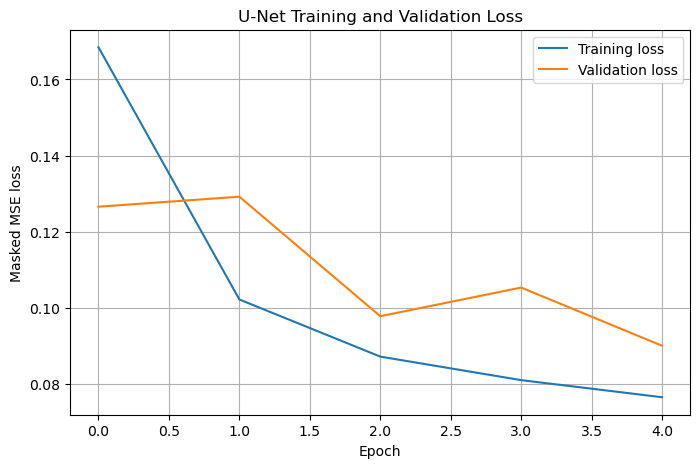

In [ ]:
epochs_ran = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["loss"], label="Training loss")
plt.plot(epochs_ran, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Masked MSE loss")
plt.title("U-Net Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [24]:
best_model = tf.keras.models.load_model(
    checkpoint_path,
    custom_objects={
        "masked_mse": masked_mse,
        "masked_mae": masked_mae,
        "masked_bias": masked_bias
    }
)

pred_test_norm_padded = best_model.predict(test_ds)

print(pred_test_norm_padded.shape)

728/728 ━━━━━━━━━━━━━━━━━━━━ 103s 138ms/step
(2912, 272, 256, 1)


In [25]:
pred_test_norm = pred_test_norm_padded[:, :H, :W, 0]

pred_test = pred_test_norm * output_std + output_mean

print("Predicted test shape:")
print(pred_test.shape)

Predicted test shape:
(2912, 266, 256)


In [26]:
true_test = Y_test_hr

valid_mask_test = np.isfinite(true_test)

error = pred_test - true_test

rmse = np.sqrt(np.nanmean(np.where(valid_mask_test, error**2, np.nan)))
mae = np.nanmean(np.where(valid_mask_test, np.abs(error), np.nan))
bias = np.nanmean(np.where(valid_mask_test, error, np.nan))

true_valid = true_test[valid_mask_test]
pred_valid = pred_test[valid_mask_test]

ss_res = np.sum((true_valid - pred_valid) ** 2)
ss_tot = np.sum((true_valid - np.mean(true_valid)) ** 2)
r2 = 1 - ss_res / ss_tot

print("Final 2012 Test Metrics:")
print("RMSE:", rmse)
print("MAE:", mae)
print("Bias:", bias)
print("R²:", r2)

Final 2012 Test Metrics:
RMSE: 2.3095152
MAE: 1.603912
Bias: -0.13857049
R²: 0.90926045


In [33]:
lon_plot = ds_hrdps_test["nav_lon"]

if "time_counter" in lon_plot.dims:
    lon_plot = lon_plot.isel(time_counter=0)

lat_plot = ds_hrdps_test["nav_lat"]

if "time_counter" in lat_plot.dims:
    lat_plot = lat_plot.isel(time_counter=0)

lon_plot = lon_plot.values
lat_plot = lat_plot.values

print("Fixed lon_plot shape:", lon_plot.shape)
print("Fixed lat_plot shape:", lat_plot.shape)

Fixed lon_plot shape: (266, 256)
Fixed lat_plot shape: (266, 256)


In [34]:
valid_mask_test = np.isfinite(true_test) & np.isfinite(pred_test)

error = pred_test - true_test
error_masked = np.where(valid_mask_test, error, np.nan)

In [44]:
test_times = pd.to_datetime(ds_hrdps_test.time_counter.values)

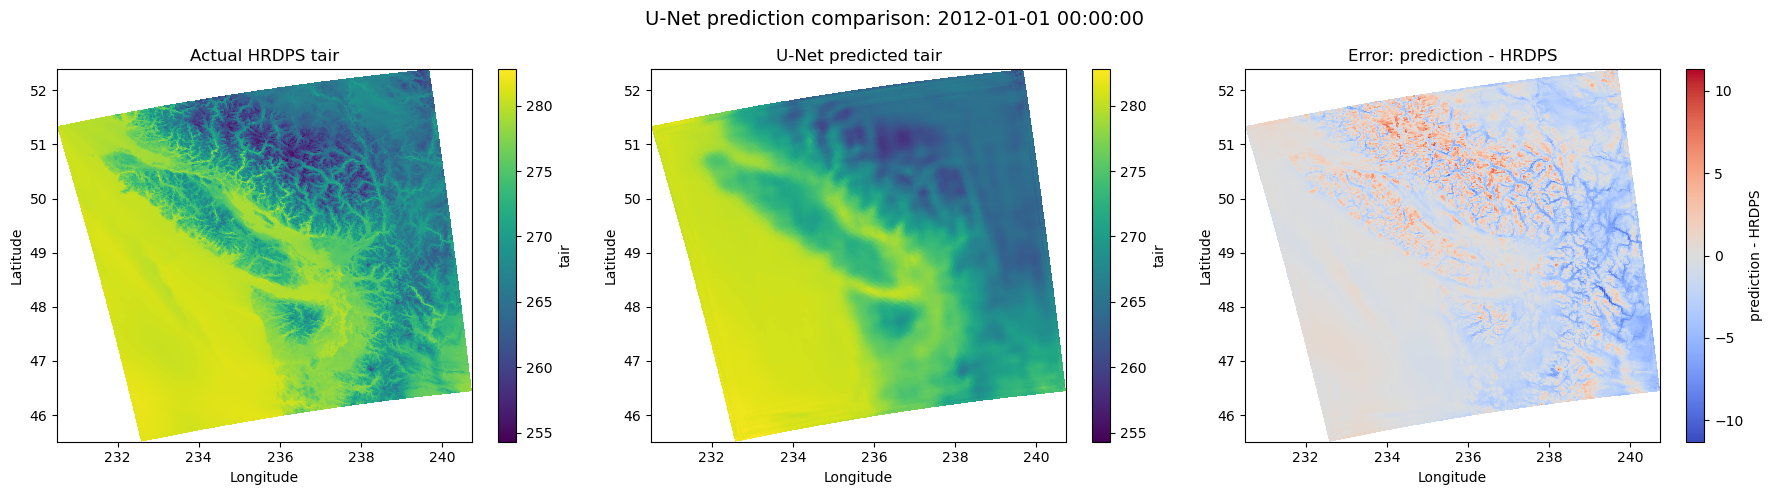

In [45]:
time_index = 0

actual_map = true_test[time_index]
predicted_map = pred_test[time_index]
error_map = predicted_map - actual_map

plot_time = test_times[time_index]

vmin = np.nanmin([np.nanmin(actual_map), np.nanmin(predicted_map)])
vmax = np.nanmax([np.nanmax(actual_map), np.nanmax(predicted_map)])

err_abs = np.nanmax(np.abs(error_map))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

p0 = axes[0].pcolormesh(
    lon_plot, lat_plot, actual_map,
    shading="auto",
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title("Actual HRDPS tair")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(p0, ax=axes[0], label="tair")

p1 = axes[1].pcolormesh(
    lon_plot, lat_plot, predicted_map,
    shading="auto",
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("U-Net predicted tair")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
plt.colorbar(p1, ax=axes[1], label="tair")

p2 = axes[2].pcolormesh(
    lon_plot, lat_plot, error_map,
    shading="auto",
    cmap="coolwarm",
    vmin=-err_abs,
    vmax=err_abs
)
axes[2].set_title("Error: prediction - HRDPS")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
plt.colorbar(p2, ax=axes[2], label="prediction - HRDPS")

plt.suptitle(f"U-Net prediction comparison: {plot_time}", fontsize=14)
plt.tight_layout()
plt.show()

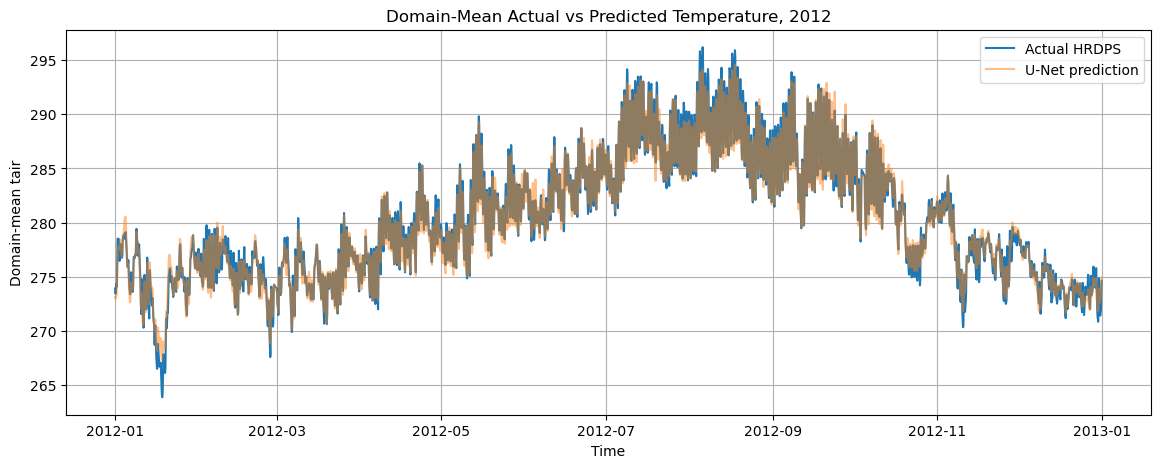

In [62]:
actual_mean_time = np.nanmean(np.where(valid_mask_test, true_test, np.nan), axis=(1, 2))
pred_mean_time = np.nanmean(np.where(valid_mask_test, pred_test, np.nan), axis=(1, 2))

plt.figure(figsize=(14, 5))
plt.plot(test_times, actual_mean_time, label="Actual HRDPS")
plt.plot(test_times, pred_mean_time, label="U-Net prediction",alpha=0.5)
plt.xlabel("Time")
plt.ylabel("Domain-mean tair")
plt.title("Domain-Mean Actual vs Predicted Temperature, 2012")
plt.legend()
plt.grid()
plt.show()

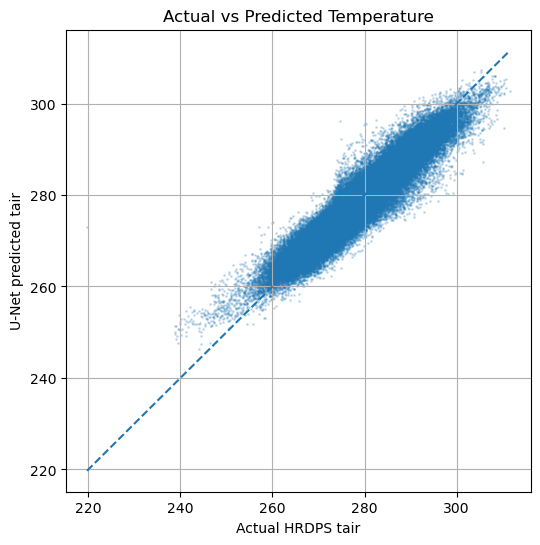

In [47]:
true_valid = true_test[valid_mask_test]
pred_valid = pred_test[valid_mask_test]

sample_size = 200000

if len(true_valid) > sample_size:
    sample_idx = np.random.choice(len(true_valid), sample_size, replace=False)
    true_sample = true_valid[sample_idx]
    pred_sample = pred_valid[sample_idx]
else:
    true_sample = true_valid
    pred_sample = pred_valid

plt.figure(figsize=(6, 6))
plt.scatter(true_sample, pred_sample, s=1, alpha=0.2)

min_val = min(np.nanmin(true_sample), np.nanmin(pred_sample))
max_val = max(np.nanmax(true_sample), np.nanmax(pred_sample))

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual HRDPS tair")
plt.ylabel("U-Net predicted tair")
plt.title("Actual vs Predicted Temperature")
plt.grid()
plt.show()

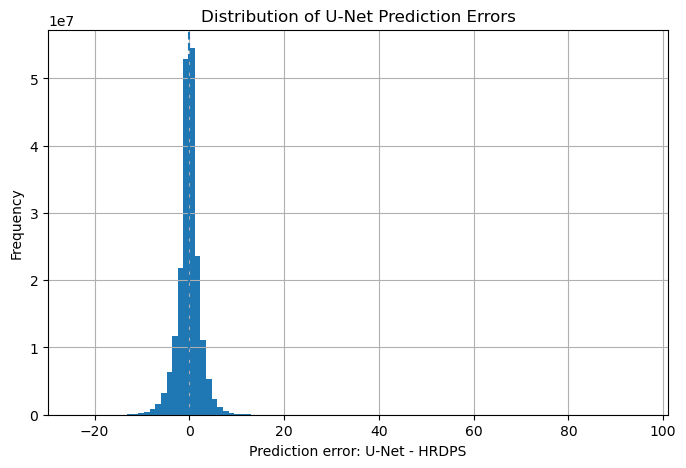

In [48]:
error_valid = error_masked[np.isfinite(error_masked)]

plt.figure(figsize=(8, 5))
plt.hist(error_valid, bins=100)
plt.axvline(0, linestyle="--")
plt.xlabel("Prediction error: U-Net - HRDPS")
plt.ylabel("Frequency")
plt.title("Distribution of U-Net Prediction Errors")
plt.grid()
plt.show()

In [49]:
rmse_each_time = np.sqrt(np.nanmean(error_masked ** 2, axis=(1, 2)))
mae_each_time = np.nanmean(np.abs(error_masked), axis=(1, 2))
bias_each_time = np.nanmean(error_masked, axis=(1, 2))

daily_errors = pd.DataFrame({
    "time": test_times,
    "date": test_times.normalize(),
    "rmse": rmse_each_time,
    "mae": mae_each_time,
    "bias": bias_each_time
})

daily_errors = daily_errors.groupby("date").mean(numeric_only=True)

daily_errors.head()

,rmse,mae,bias
date,,,
2012-01-01,2.061712,1.494620,-0.838781
2012-01-02,2.365278,1.704419,-0.065399
2012-01-03,1.647568,1.220317,-0.071282
2012-01-04,2.044241,1.652610,1.071888
2012-01-05,1.760354,1.283305,0.207559


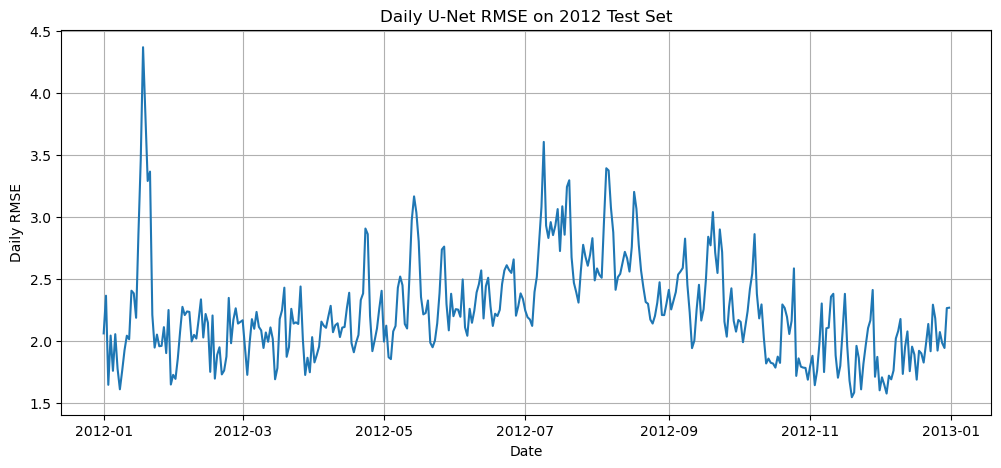

In [50]:
plt.figure(figsize=(12, 5))
plt.plot(daily_errors.index, daily_errors["rmse"])
plt.xlabel("Date")
plt.ylabel("Daily RMSE")
plt.title("Daily U-Net RMSE on 2012 Test Set")
plt.grid()
plt.show()

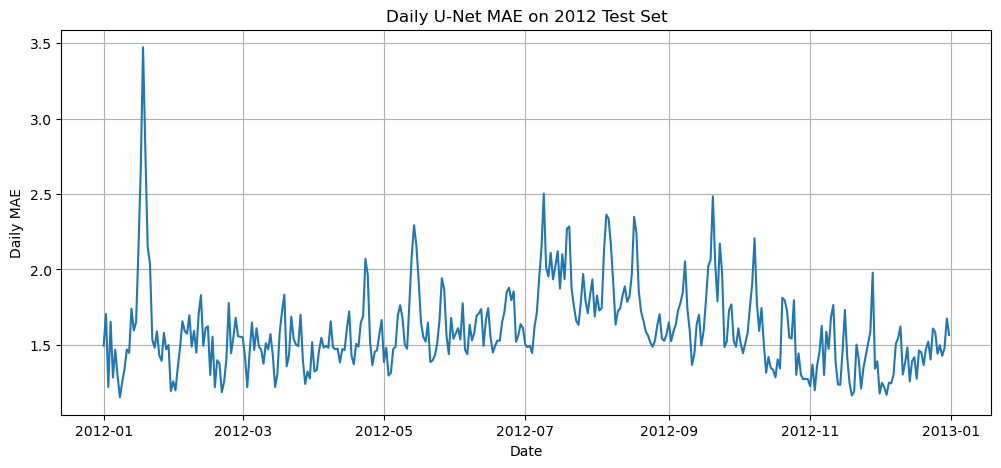

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(daily_errors.index, daily_errors["mae"])
plt.xlabel("Date")
plt.ylabel("Daily MAE")
plt.title("Daily U-Net MAE on 2012 Test Set")
plt.grid()
plt.show()

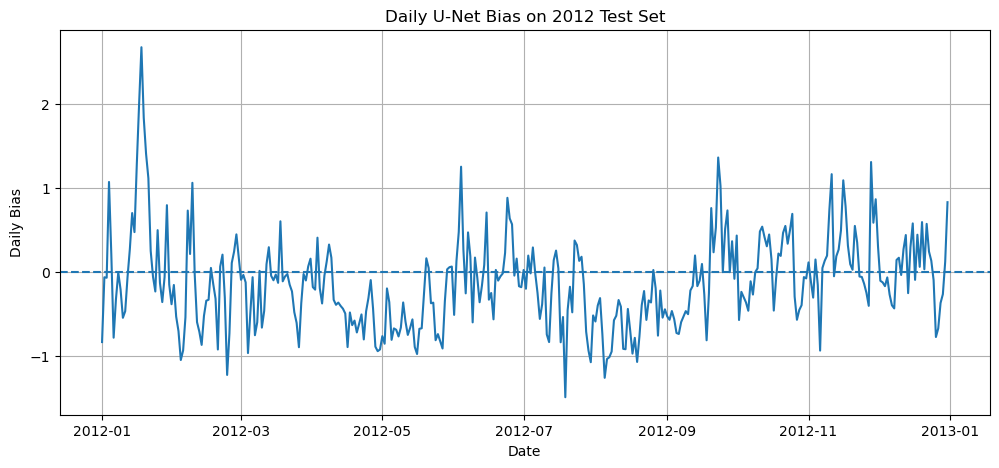

In [52]:
plt.figure(figsize=(12, 5))
plt.plot(daily_errors.index, daily_errors["bias"])
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Daily Bias")
plt.title("Daily U-Net Bias on 2012 Test Set")
plt.grid()
plt.show()

<Figure size 1000x500 with 0 Axes>

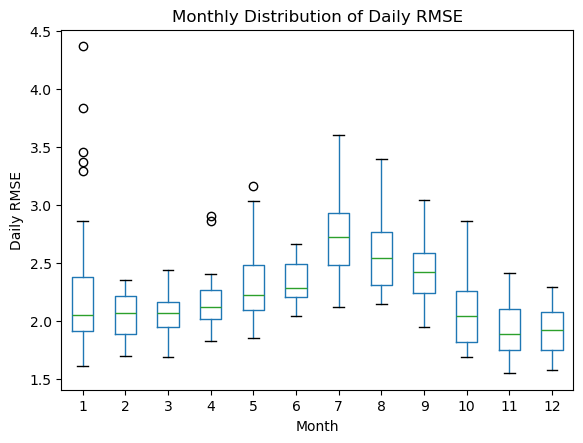

In [53]:
daily_errors_for_box = daily_errors.copy()
daily_errors_for_box["month"] = daily_errors_for_box.index.month

plt.figure(figsize=(10, 5))
daily_errors_for_box.boxplot(column="rmse", by="month")

plt.xlabel("Month")
plt.ylabel("Daily RMSE")
plt.title("Monthly Distribution of Daily RMSE")
plt.suptitle("")
plt.grid()
plt.show()